## Imports

In [3]:
import cv2 as cv # OpenCV (Open Source Computer Vision Library) 
import numpy as np
import matplotlib.pyplot as plt

import Functions as func
import ROI as r
import Vis as vis
import CompVis as comp_vis
from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [5]:
nPC = 12
reduction_factor = 0.2
out_video_path = 'out/w_wo_water/'
nframes = 800
fps = 240
n_peaks = 5

### variation over time

In [2]:
names = ['videos/8days/20260207/240/VID_20260207_081701560.mp4', 
         'videos/8days/20260208/240/VID_20260208_071551134.mp4',
         'videos/8days/20260209/240/VID_20260209_075208490.mp4',
         'videos/8days/20260210/240/VID_20260210_073714886.mp4',
         'videos/8days/20260211/240/VID_20260211_072715346.mp4',
         'videos/8days/20260212/240/VID_20260212_072409310.mp4',
         'videos/8days/20260213/240/VID_20260213_073426768.mp4',
         'videos/8days/20260214/240/VID_20260214_040340493.mp4',
         'videos/new_videos/20260403/240/VID_20260403_093930290.mp4',
         'videos/new_videos/20260404/240/VID_20260404_083559178.mp4',
         'videos/new_videos/20260405/240/VID_20260405_081814881.mp4',
         'videos/new_videos/20260406/240/VID_20260406_073657130.mp4',
         'videos/new_videos/20260407/240/VID_20260407_072634451.mp4',
         'videos/new_videos/20260408/240/VID_20260408_073141468.mp4',
         'videos/new_videos/20260409/240/VID_20260409_062613791.mp4',
         'videos/new_videos/20260410/240/VID_20260410_072958947.mp4']

rois = r.load_rois()

In [ ]:
# for i, name in enumerate(names):
#     print(f'{name} processing...', end = ' ')
#     file_name = name.split('/')[-1]
#     comp_vis.pre_processing(name, out_video_path + file_name, nframes, fps, reduction_factor, rois[file_name])
#     print(f'done.')

### Pipeline over time

In [14]:
results = {}
for name in names:
    video_name = out_video_path + name.split('/')[-1]
    unmixed = comp_vis.la_pipeline(video_name, nPC)    
    vf = func.video_status(video_file, verbose = False)
    
    fft_data = comp_vis.compute_fft_for_components(unmixed, vf["fps"], range(nPC))
    peaks_info = comp_vis.get_highest_peak_frequencies(fft_data, n_peaks)
    
    results[name] = [p['highest_freq'] for p in peaks_info.values()]

In [18]:
results2 = {}
for key, values in results.items():
    for i, v in enumerate(values):
        if i not in results2:
            results2[i] = []
        results2[i].append(v)

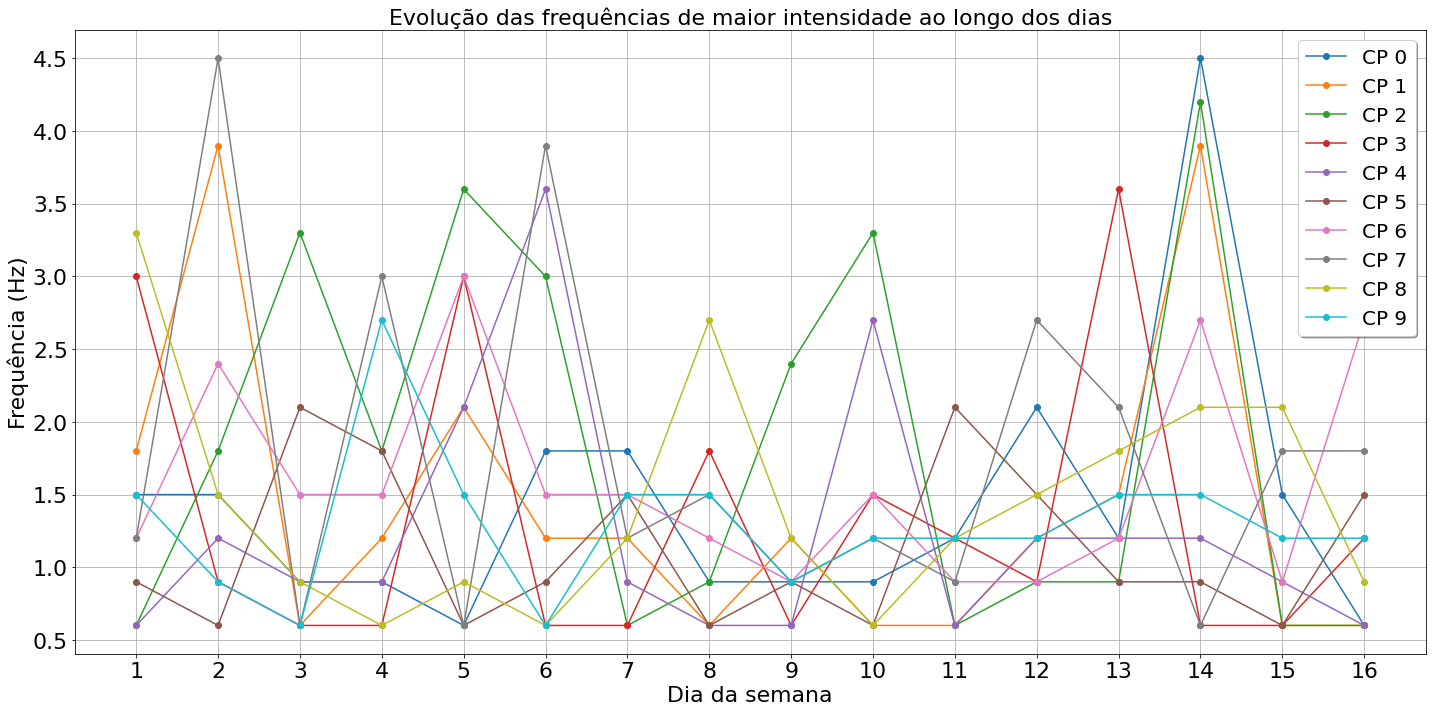

In [23]:
dias = list(range(1, len(names) + 1))

plt.figure(figsize=(20, 10))

for componente, valores in results2.items():
    plt.plot(dias, valores, marker='o', label=f'CP {componente}')

plt.xlabel('Dia da semana', fontsize = 22)
plt.ylabel('Frequência (Hz)', fontsize = 22)
plt.title('Evolução das frequências de maior intensidade ao longo dos dias', fontsize = 22)
plt.xticks(dias)
plt.legend(loc = 'upper right', fancybox = True, shadow = True, fontsize = 20)
plt.tick_params(axis = 'both', labelsize = 22)
plt.grid(True)
plt.tight_layout()

In [26]:
results3 = list(map(lambda x: np.mean(x), results.values()))

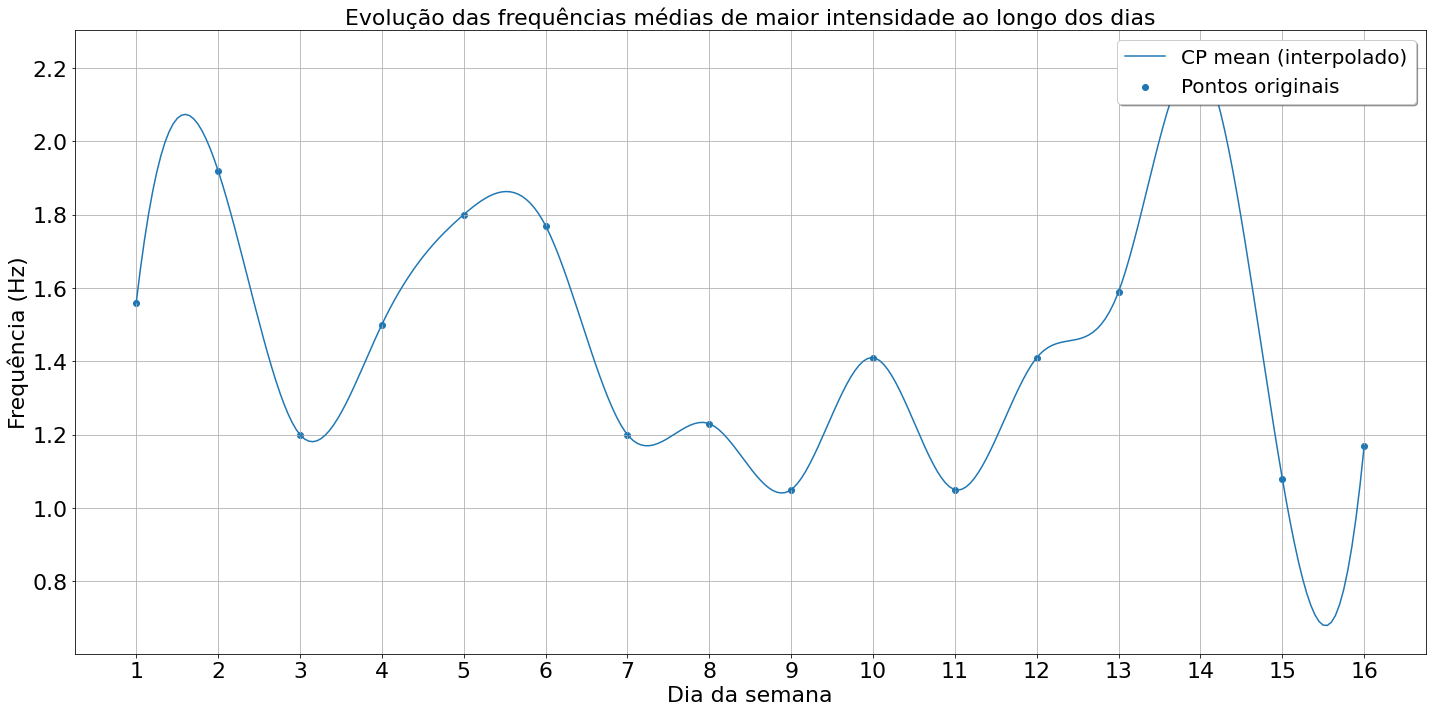

In [27]:
dias = np.array(list(range(1, len(names) + 1)))
y = np.array(results3)

# cria novos pontos mais densos (suavização)
dias_smooth = np.linspace(dias.min(), dias.max(), 300)

# interpolação spline cúbica
spline = make_interp_spline(dias, y, k=3)
y_smooth = spline(dias_smooth)

plt.figure(figsize=(20, 10))

# curva suave
plt.plot(dias_smooth, y_smooth, label='CP mean (interpolado)')

# pontos originais
plt.scatter(dias, y, label='Pontos originais')

plt.xlabel('Dia da semana', fontsize=22)
plt.ylabel('Frequência (Hz)', fontsize=22)
plt.title('Evolução das frequências médias de maior intensidade ao longo dos dias', fontsize=22)
plt.xticks(dias)
plt.legend(loc='upper right', fancybox=True, shadow=True, fontsize=20)
plt.tick_params(axis='both', labelsize=22)
plt.grid(True)
plt.tight_layout()

plt.show()

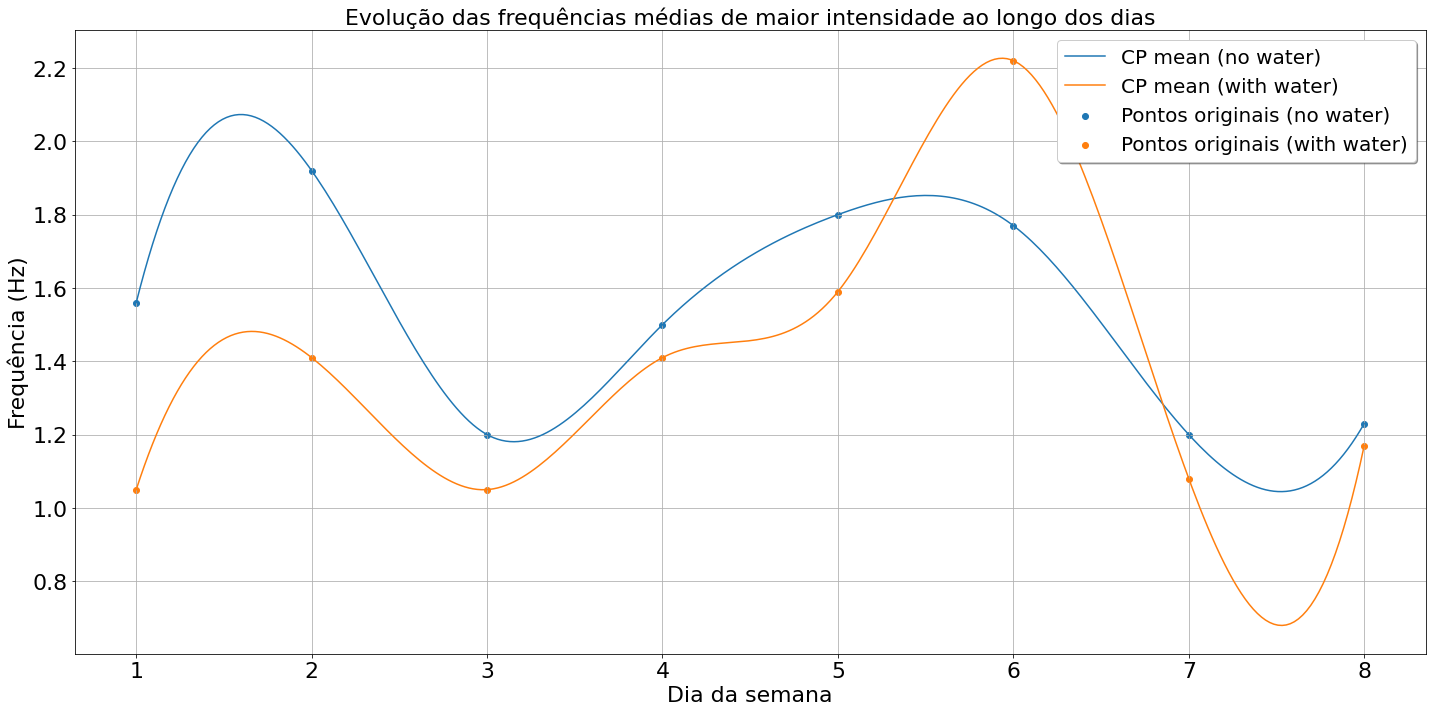

In [32]:
dias = np.array(list(range(1, 9)))
y1 = np.array(results3[:8])
y2 = np.array(results3[8:])

# cria novos pontos mais densos (suavização)
dias_smooth = np.linspace(dias.min(), dias.max(), 300)

# interpolação spline cúbica
spline = make_interp_spline(dias, y1, k=3)
y_smooth1 = spline(dias_smooth)

spline = make_interp_spline(dias, y2, k=3)
y_smooth2 = spline(dias_smooth)

plt.figure(figsize=(20, 10))

# curva suave
plt.plot(dias_smooth, y_smooth1, label='CP mean (no water)')
plt.plot(dias_smooth, y_smooth2, label='CP mean (with water)')

# pontos originais
plt.scatter(dias, y1, label='Pontos originais (no water)')
plt.scatter(dias, y2, label='Pontos originais (with water)')

plt.xlabel('Dia da semana', fontsize=22)
plt.ylabel('Frequência (Hz)', fontsize=22)
plt.title('Evolução das frequências médias de maior intensidade ao longo dos dias', fontsize=22)
plt.xticks(dias)
plt.legend(loc='upper right', fancybox=True, shadow=True, fontsize=20)
plt.tick_params(axis='both', labelsize=22)
plt.grid(True)
plt.tight_layout()

plt.savefig('out/pipeline_over_time.png', bbox_inches = 'tight')

### spectrogram

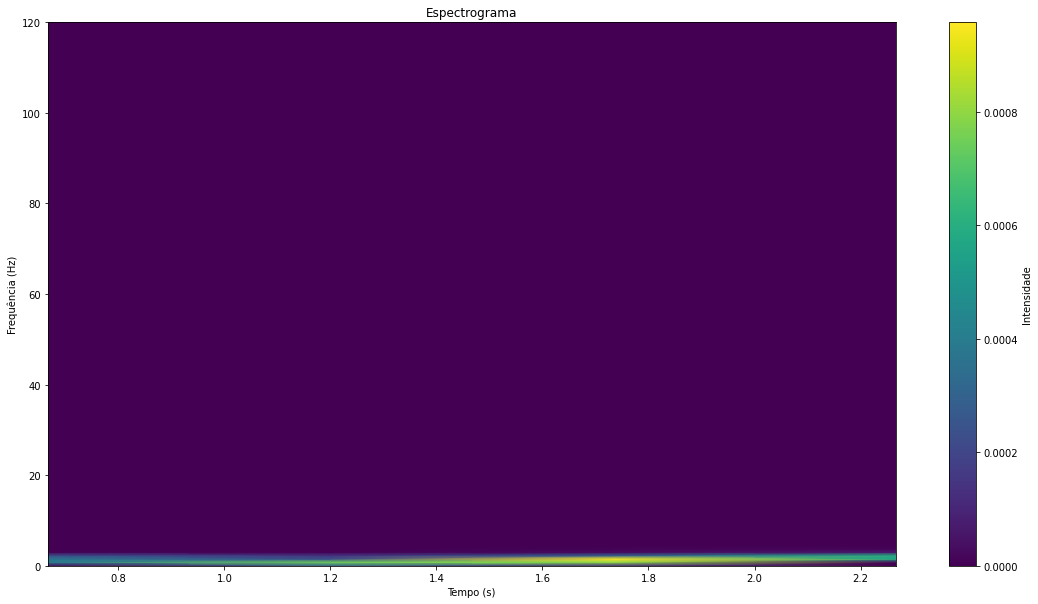

<Figure size 432x288 with 0 Axes>

In [21]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

fs = 240 # fps do vídeo

f, t, Sxx = spectrogram(
    unmixed[:, 1],
    fs=fs,
    window='hann',
    nperseg=320,
    noverlap=192
)
plt.figure(figsize = [19, 10])
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequência (Hz)")
plt.xlabel("Tempo (s)")
plt.title("Espectrograma")
plt.colorbar(label="Intensidade")
plt.show()
plt.savefig('out/spect.png', bbox_inches = 'tight')